

## Objective

The objective of this notebook is to prepare the datasets for machine learning model development.

The preprocessing pipeline includes:

- Data Cleaning
- Data Type Conversion
- Feature Engineering
- Dataset Integration
- Encoding Categorical Features
- Feature Scaling
- Preparing ML-ready datasets

This notebook creates the final datasets that will be used in subsequent notebooks for:

- Flight Price Prediction
- Gender Classification
- Hotel Recommendation System

# Import Required Libraries

The following libraries are used for preprocessing, feature engineering, encoding, and machine learning preparation.

In [58]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Load Raw Datasets

The datasets generated during the data collection phase are loaded for preprocessing.

In [59]:
users = pd.read_csv("../data/raw/users.csv")

flights = pd.read_csv("../data/raw/flights.csv")

hotels = pd.read_csv("../data/raw/hotels.csv")

# Create Working Copies

To preserve the original datasets, copies are created before applying preprocessing operations.

In [60]:
users_df = users.copy()
flights_df = flights.copy()
hotels_df = hotels.copy()

# Initial Verification

Before preprocessing, the dimensions of each dataset are verified to ensure that the data has been loaded correctly.

In [61]:
print("Users :", users_df.shape)
print("Flights :", flights_df.shape)
print("Hotels :", hotels_df.shape)

Users : (1340, 5)
Flights : (271888, 10)
Hotels : (40552, 8)


# Verify Data Types

This step verifies the data types of all features before applying preprocessing techniques.

In [62]:
users_df.dtypes

code        int64
company    object
name       object
gender     object
age         int64
dtype: object

In [63]:
flights_df.dtypes

travelCode      int64
userCode        int64
from           object
to             object
flightType     object
price         float64
time          float64
distance      float64
agency         object
date           object
dtype: object

In [64]:
hotels_df.dtypes

travelCode      int64
userCode        int64
name           object
place          object
days            int64
price         float64
total         float64
date           object
dtype: object

# Preprocessing Steps

## Step 1- Date Conversion

The `date` column is converted from string format to datetime format.

This enables extraction of temporal features that improve model performance.

In [65]:
flights_df["date"] = pd.to_datetime(flights_df["date"])

hotels_df["date"] = pd.to_datetime(hotels_df["date"])

### Verify Date Conversion

In [66]:
print(flights_df["date"].dtype)

print(hotels_df["date"].dtype)

datetime64[ns]
datetime64[ns]


## Step 2- Date Feature Engineering

Instead of using the complete date, meaningful temporal features are extracted.

These include:

- Year
- Month
- Day
- Day of Week

Temporal features often improve the predictive performance of machine learning models.

In [67]:
flights_df["year"] = flights_df["date"].dt.year
flights_df["month"] = flights_df["date"].dt.month
flights_df["day"] = flights_df["date"].dt.day
flights_df["day_of_week"] = flights_df["date"].dt.day_name()

hotels_df["year"] = hotels_df["date"].dt.year
hotels_df["month"] = hotels_df["date"].dt.month
hotels_df["day"] = hotels_df["date"].dt.day
hotels_df["day_of_week"] = hotels_df["date"].dt.day_name()

### Verify Feature Engineering

In [68]:
display(flights_df.head())

display(hotels_df.head())

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date,year,month,day,day_of_week
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26,2019,9,26,Thursday
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30,2019,9,30,Monday
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03,2019,10,3,Thursday
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04,2019,10,4,Friday
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10,2019,10,10,Thursday


,travelCode,userCode,name,place,days,price,total,date,year,month,day,day_of_week
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26,2019,9,26,Thursday
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10,2019,10,10,Thursday
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14,2019,11,14,Thursday
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,2019-12-12,2019,12,12,Thursday
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,2019-12-26,2019,12,26,Thursday


## Step 3- Check Primary keys

In [69]:
print("Users Code Unique :", users_df["code"].is_unique)

print("Flights TravelCode Unique :", flights_df["travelCode"].is_unique)

print("Hotels TravelCode Unique :", hotels_df["travelCode"].is_unique)

print("Flights UserCode Unique :", flights_df["userCode"].is_unique)

print("Hotels UserCode Unique :", hotels_df["userCode"].is_unique)

Users Code Unique : True
Flights TravelCode Unique : False
Hotels TravelCode Unique : True
Flights UserCode Unique : False
Hotels UserCode Unique : False


## Step 4- Relationship Check

In [70]:
print(users_df.columns)

print(flights_df.columns)

print(hotels_df.columns)

Index(['code', 'company', 'name', 'gender', 'age'], dtype='object')
Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')
Index(['travelCode', 'userCode', 'name', 'place', 'days', 'price', 'total',
       'date', 'year', 'month', 'day', 'day_of_week'],
      dtype='object')


# Dataset Relationship Validation

Before integrating datasets, it is important to validate the uniqueness of primary and foreign keys.

The relationship analysis confirms:

- `code` is the primary key of the Users dataset.
- `userCode` acts as a foreign key in both Flights and Hotels datasets.
- `travelCode` uniquely identifies hotel bookings but may correspond to multiple flight records.
- These relationships form the basis of the machine learning pipeline and recommendation engine.

## Primary Key Summary

In [71]:
key_summary = pd.DataFrame({
    "Dataset": [
        "Users",
        "Flights",
        "Flights",
        "Hotels",
        "Hotels"
    ],
    "Key":[
        "code",
        "travelCode",
        "userCode",
        "travelCode",
        "userCode"
    ],
    "Unique":[
        users_df["code"].is_unique,
        flights_df["travelCode"].is_unique,
        flights_df["userCode"].is_unique,
        hotels_df["travelCode"].is_unique,
        hotels_df["userCode"].is_unique
    ]
})

key_summary

,Dataset,Key,Unique
0,Users,code,True
1,Flights,travelCode,False
2,Flights,userCode,False
3,Hotels,travelCode,True
4,Hotels,userCode,False


### Visualization

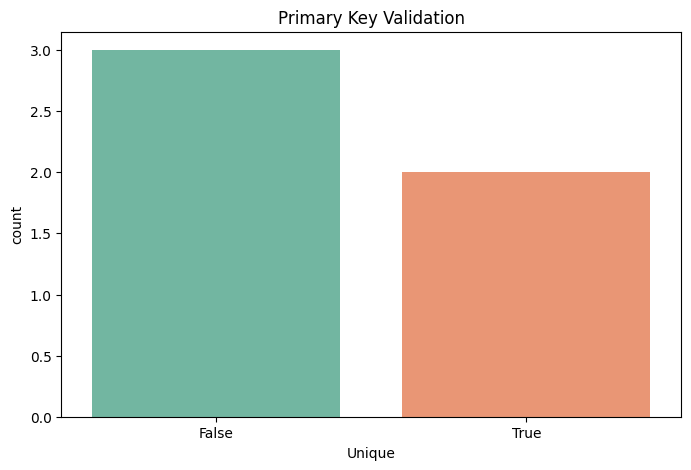

In [72]:
from IPython.core import async_helpers
plt.figure(figsize=(8,5))

sns.countplot(
    data=key_summary,
    x="Unique",
    palette="Set2"
)

plt.title("Primary Key Validation")

plt.show()

### Observation

The Users dataset contains a unique identifier (`code`) for every customer.

The Flights dataset contains multiple flight records for individual travel itineraries, resulting in repeated `travelCode` values.

The Hotels dataset contains unique travel identifiers, indicating one hotel booking per travel itinerary.

The relationships validate that:

- One user can have multiple flights.
- One user can have multiple hotel bookings.
- A travel itinerary can contain multiple flights but one hotel booking.

# Conclusion

In this notebook, the raw datasets were successfully prepared for machine learning.

## Tasks Completed

- Verified dataset integrity
- Validated primary and foreign key relationships
- Converted date columns into datetime format
- Extracted temporal features such as year, month, day, and day of week
- Confirmed relationships between Users, Flights, and Hotels datasets

## Key Findings

- Users dataset contains unique customer identifiers.
- Flights dataset represents multiple flight records for a travel itinerary.
- Hotels dataset contains unique hotel bookings linked through travelCode.
- The datasets are now ready for model-specific preprocessing.

## Next Steps

The next notebook focuses on **Flight Price Prediction**, where the Users and Flights datasets will be merged, followed by feature engineering, encoding, model training, and evaluation.